# Federated Learning for MNIST Handwritten Digit Classification

Copyright 2026 Tsung-Tang Lee (also known as Osborn Lee or Moe)

---

## Objective

This project demonstrates a simple Federated Learning framework for handwritten digit classification using the MNIST dataset.

Unlike traditional centralized machine learning, Federated Learning allows each client to keep its own training data locally while only sharing model parameters with the server.

The server aggregates all local models using the Federated Averaging (FedAvg) algorithm to build a global model.

---

## Workflow

MNIST Dataset

↓

Split into Multiple Clients

↓

Local CNN Training

↓

Upload Model Weights

↓

FedAvg Aggregation

↓

Global CNN Model

↓

Repeat Communication Rounds

---

## Tools

- Google Colab
- Python
- TensorFlow / Keras
- NumPy
- Matplotlib
- Scikit-Learn

---

## Dataset

MNIST Handwritten Digits

Training Images : 60,000

Testing Images : 10,000

Image Size : 28×28

Number of Classes : 10

In [ ]:
# ==========================================
# Import Libraries
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import mnist

print("TensorFlow Version :", tf.__version__)
print("NumPy Version :", np.__version__)

# 固定亂數種子，讓每次實驗結果更容易重現
np.random.seed(42)
tf.random.set_seed(42)

print("\nEnvironment Ready!")

TensorFlow Version : 2.20.0
NumPy Version : 2.0.2

Environment Ready!


In [ ]:
# ==========================================
# Load MNIST Dataset
# ==========================================
# 載入MNIST資料集

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)

print()

print("Testing Images Shape :", x_test.shape)
print("Testing Labels Shape :", y_test.shape)

print()

print("Image Height :", x_train.shape[1])

print("Image Width :", x_train.shape[2])

print()

print("Number of Classes :", len(np.unique(y_train)))

print("Class Labels :", np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)

Testing Images Shape : (10000, 28, 28)
Testing Labels Shape : (10000,)

Image Height : 28
Image Width : 28

Number of Classes : 10
Class Labels : [0 1 2 3 4 5 6 7 8 9]


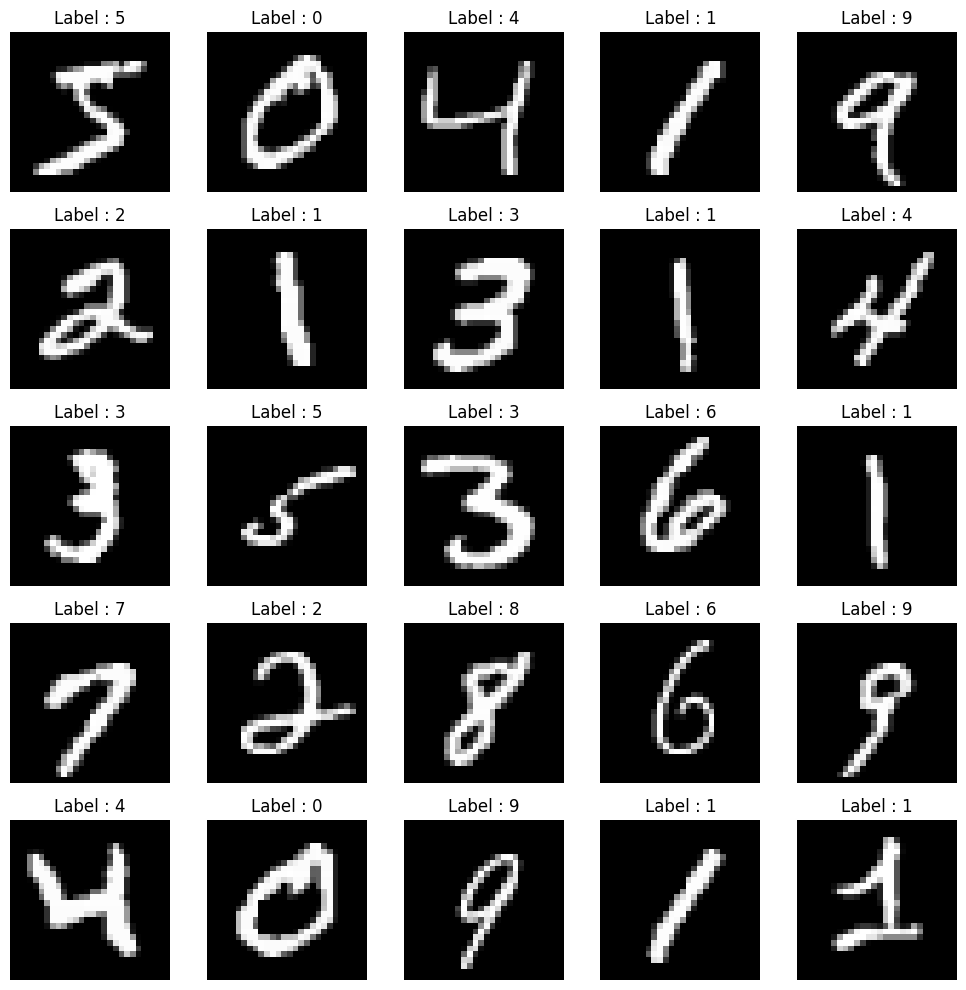

In [ ]:
# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

import matplotlib.pyplot as plt

# 顯示前25張圖片
plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.imshow(x_train[i], cmap="gray")

    plt.title(f"Label : {y_train[i]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

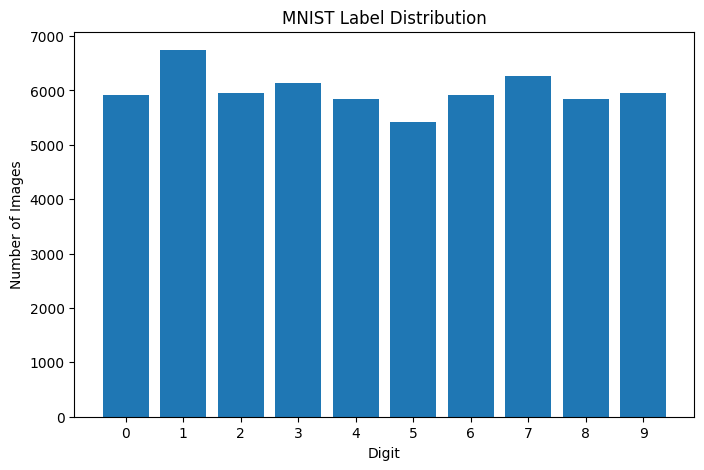

Label Distribution
Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


In [ ]:
# ==========================================
# Label Distribution
# ==========================================

import numpy as np

labels, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8,5))

plt.bar(labels, counts)

plt.xlabel("Digit")

plt.ylabel("Number of Images")

plt.title("MNIST Label Distribution")

plt.xticks(labels)

plt.show()

print("Label Distribution")

for label, count in zip(labels, counts):

    print(f"Digit {label}: {count}")

In [ ]:
# ==========================================
# Data Normalization
# MNIST : 0 - 255
# To
# CNN  : 0 - 1
# ==========================================

# 轉成float32
x_train = x_train.astype("float32")

x_test = x_test.astype("float32")

# Normalize
x_train = x_train / 255.0

x_test = x_test / 255.0

# CNN 需要 Channel Dimension
x_train = np.expand_dims(x_train, axis=-1)

x_test = np.expand_dims(x_test, axis=-1)

print("Training Shape :", x_train.shape)

print("Testing Shape :", x_test.shape)

print()

print("Minimum Pixel :", x_train.min())

print("Maximum Pixel :", x_train.max())

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)

Minimum Pixel : 0.0
Maximum Pixel : 1.0


In [ ]:
# ==========================================
# Split Dataset into Clients
# 開始 Federated Learning
# ==========================================

NUM_CLIENTS = 5

client_data = []

client_size = len(x_train) // NUM_CLIENTS

for i in range(NUM_CLIENTS):

    start = i * client_size

    end = (i + 1) * client_size

    client_x = x_train[start:end]

    client_y = y_train[start:end]

    client_data.append((client_x, client_y))

    print(
        f"Client {i+1}:",
        client_x.shape,
        client_y.shape
    )

Client 1: (12000, 28, 28, 1) (12000,)
Client 2: (12000, 28, 28, 1) (12000,)
Client 3: (12000, 28, 28, 1) (12000,)
Client 4: (12000, 28, 28, 1) (12000,)
Client 5: (12000, 28, 28, 1) (12000,)


In [ ]:
# ==========================================
# Build CNN Model
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

def create_model():

    model = Sequential([

        Conv2D(
            filters=32,
            kernel_size=(3,3),
            activation='relu',
            input_shape=(28,28,1)
        ),

        MaxPooling2D(pool_size=(2,2)),

        Conv2D(
            filters=64,
            kernel_size=(3,3),
            activation='relu'
        ),

        MaxPooling2D(pool_size=(2,2)),

        Flatten(),

        Dense(128, activation='relu'),

        Dropout(0.5),

        Dense(10, activation='softmax')

    ])

    model.compile(

        optimizer='adam',

        loss='sparse_categorical_crossentropy',

        metrics=['accuracy']

    )

    return model


# 建立模型
global_model = create_model()

# 顯示模型架構
global_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================================
# Weight Functions
# ==========================================

def get_weights(model):

    return model.get_weights()


def set_weights(model, weights):

    model.set_weights(weights)

In [ ]:
# ==========================================
# Local Training
# ==========================================

LOCAL_EPOCHS = 1
BATCH_SIZE = 64

def local_training(client_x, client_y, global_weights):

    model = create_model()

    # 載入Global Model
    set_weights(model, global_weights)

    # Local Training
    history = model.fit(

        client_x,

        client_y,

        epochs=LOCAL_EPOCHS,

        batch_size=BATCH_SIZE,

        verbose=0

    )

    return model.get_weights(), history.history

In [ ]:
# ==========================================
# FedAvg Aggregation
# ==========================================

import numpy as np

def fedavg(client_weights):

    new_weights = []

    # 每一層CNN
    for weights_list in zip(*client_weights):

        new_weights.append(

            np.mean(weights_list, axis=0)

        )

    return new_weights

In [ ]:
# ==========================================
# Federated Learning Configuration
# and Weighted FedAvg
# ==========================================

import numpy as np
import time

# 聯邦學習參數
NUM_ROUNDS = 10
LOCAL_EPOCHS = 1
BATCH_SIZE = 64

print("Federated Learning Configuration")
print("----------------------------------------------------------------")
print("Number of Clients     :", len(client_data))
print("Communication Rounds    :", NUM_ROUNDS)
print("Local Epochs per Round  :", LOCAL_EPOCHS)
print("Batch Size         :", BATCH_SIZE)


def weighted_fedavg(client_weights, client_sizes):
    """
    使用每個 Client 的資料量執行加權 Federated Averaging。

    Parameters
    ----------
    client_weights : list
        每個 Client 訓練後的模型權重。

    client_sizes : list
        每個 Client 的訓練資料數量。

    Returns
    -------
    averaged_weights : list
        聚合後的 Global Model 權重。
    """

    # 所有參與 Client 的總資料量
    total_samples = sum(client_sizes)

    # 檢查輸入資料是否合法
    if total_samples == 0:
        raise ValueError("Client total sample size cannot be zero.")

    if len(client_weights) != len(client_sizes):
        raise ValueError(
            "The number of client weights must match "
            "the number of client sizes."
        )

    averaged_weights = []

    # client_weights[0] 是第一個 Client 的全部模型參數
    # len(client_weights[0]) 是模型中 Weight Array 的數量
    for layer_index in range(len(client_weights[0])):

        # 建立一個與該層權重 Shape 相同的全零矩陣
        weighted_layer = np.zeros_like(
            client_weights[0][layer_index]
        )

        # 將所有 Client 在同一層的權重進行加權累加
        for weights, client_size in zip(
            client_weights,
            client_sizes
        ):
            client_ratio = client_size / total_samples

            weighted_layer += (
                weights[layer_index] * client_ratio
            )

        averaged_weights.append(weighted_layer)

    return averaged_weights

Federated Learning Configuration
----------------------------------------------------------------
Number of Clients     : 5
Communication Rounds    : 10
Local Epochs per Round  : 1
Batch Size         : 64


In [ ]:
# ==========================================
# Federated Training Loop
# ==========================================

# 建立一個全新的 Global Model
# 這樣可以確保訓練從隨機初始化開始
global_model = create_model()

# 取得初始 Global Weights
global_weights = global_model.get_weights()

# 記錄每一輪 Global Model 的表現
global_test_loss_history = []
global_test_accuracy_history = []

# 記錄每一輪 Client Local Training 的平均表現
local_loss_history = []
local_accuracy_history = []

# 記錄每一輪花費的時間
round_time_history = []


# ------------------------------------------------
# Round 0：模型還沒有經過任何 Federated Training
# ------------------------------------------------

initial_test_loss, initial_test_accuracy = global_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

global_test_loss_history.append(initial_test_loss)
global_test_accuracy_history.append(initial_test_accuracy)

print("=" * 65) # 就是 ============================================= ... 就 65個 =
print("Initial Global Model Evaluation")
print("=" * 65) # 就是 ============================================= ... 就 65個 =
print(f"Round 0 Test Loss     : {initial_test_loss:.4f}")
print(f"Round 0 Test Accuracy : {initial_test_accuracy:.4f}")
print()


# ------------------------------------------------
# 開始 Federated Learning
# ------------------------------------------------

for round_number in range(1, NUM_ROUNDS + 1):

    round_start_time = time.time()

    print("=" * 65) # 就是 ============================================= ... 就 65個 =
    print(f"Communication Round {round_number}/{NUM_ROUNDS}")
    print("=" * 65) # 就是 ============================================= ... 就 65個 =

    # 儲存每個 Client 訓練完成後的模型權重
    client_weights_list = []

    # 儲存每個 Client 的資料量
    client_sizes = []

    # 儲存每個 Client 的 Local Loss 與 Accuracy
    client_losses = []
    client_accuracies = []

    # --------------------------------------------
    # 逐一執行每個 Client 的 Local Training
    # --------------------------------------------

    for client_index, (client_x, client_y) in enumerate(
        client_data
    ):

        client_number = client_index + 1

        # 每個 Client 都從相同的 Global Weights 開始訓練
        local_weights, local_history = local_training(
            client_x=client_x,
            client_y=client_y,
            global_weights=global_weights
        )

        # 儲存 Client 訓練後的 Weight
        client_weights_list.append(local_weights)

        # 儲存 Client 資料數量
        client_sizes.append(len(client_x))

        # 取得最後一個 Local Epoch 的 Loss 與 Accuracy
        client_loss = local_history["loss"][-1]
        client_accuracy = local_history["accuracy"][-1]

        client_losses.append(client_loss)
        client_accuracies.append(client_accuracy)

        print(
            f"Client {client_number}: "
            f"Samples = {len(client_x):5d}, "
            f"Local Loss = {client_loss:.4f}, "
            f"Local Accuracy = {client_accuracy:.4f}"
        )

    # --------------------------------------------
    # Server 執行 Weighted FedAvg
    # --------------------------------------------

    global_weights = weighted_fedavg(
        client_weights=client_weights_list,
        client_sizes=client_sizes
    )

    # 將聚合後的權重放回 Global Model
    global_model.set_weights(global_weights)

    # --------------------------------------------
    # 使用共同測試集評估 Global Model
    # --------------------------------------------

    global_test_loss, global_test_accuracy = (
        global_model.evaluate(
            x_test,
            y_test,
            verbose=0
        )
    )

    # 依照 Client 資料量計算加權平均 Local Metric
    total_client_samples = sum(client_sizes)

    weighted_local_loss = sum(
        loss * size
        for loss, size in zip(client_losses, client_sizes)
    ) / total_client_samples

    weighted_local_accuracy = sum(
        accuracy * size
        for accuracy, size
        in zip(client_accuracies, client_sizes)
    ) / total_client_samples

    # 儲存本輪結果
    local_loss_history.append(weighted_local_loss)
    local_accuracy_history.append(weighted_local_accuracy)

    global_test_loss_history.append(global_test_loss)
    global_test_accuracy_history.append(
        global_test_accuracy
    )

    # 計算本輪執行時間
    round_time = time.time() - round_start_time
    round_time_history.append(round_time)

    print("-" * 65)
    print(
        f"Average Local Loss     : "
        f"{weighted_local_loss:.4f}"
    )
    print(
        f"Average Local Accuracy : "
        f"{weighted_local_accuracy:.4f}"
    )
    print(
        f"Global Test Loss       : "
        f"{global_test_loss:.4f}"
    )
    print(
        f"Global Test Accuracy   : "
        f"{global_test_accuracy:.4f}"
    )
    print(
        f"Round Time             : "
        f"{round_time:.2f} seconds"
    )
    print()


print("=" * 65) # 就是 ============================================= ... 就 65個 =
print("Federated Training Completed")
print("=" * 65) # 就是 ============================================= ... 就 65個 =

print(
    f"Final Global Test Loss     : "
    f"{global_test_loss_history[-1]:.4f}"
)

print(
    f"Final Global Test Accuracy : "
    f"{global_test_accuracy_history[-1]:.4f}"
)

print(
    f"Total Training Time        : "
    f"{sum(round_time_history):.2f} seconds"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Initial Global Model Evaluation
Round 0 Test Loss     : 2.3134
Round 0 Test Accuracy : 0.1046

Communication Round 1/10
Client 1: Samples = 12000, Local Loss = 0.6078, Local Accuracy = 0.8107
Client 2: Samples = 12000, Local Loss = 0.6305, Local Accuracy = 0.8008
Client 3: Samples = 12000, Local Loss = 0.6311, Local Accuracy = 0.7992
Client 4: Samples = 12000, Local Loss = 0.6478, Local Accuracy = 0.7906
Client 5: Samples = 12000, Local Loss = 0.5938, Local Accuracy = 0.8112
-----------------------------------------------------------------
Average Local Loss     : 0.6222
Average Local Accuracy : 0.8025
Global Test Loss       : 0.2033
Global Test Accuracy   : 0.9519
Round Time             : 58.92 seconds

Communication Round 2/10
Client 1: Samples = 12000, Local Loss = 0.2100, Local Accuracy = 0.9389
Client 2: Samples = 12000, Local Loss = 0.2135, Local Accuracy = 0.9372
Client 3: Samples = 12000, Local Loss = 0.2163, Local Accuracy = 0.9350
Client 4: Samples = 12000, Local Loss = 0.224

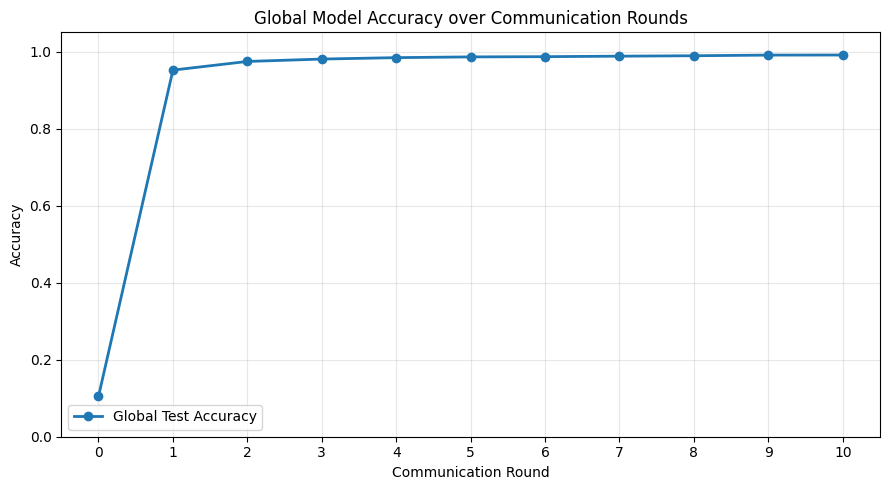

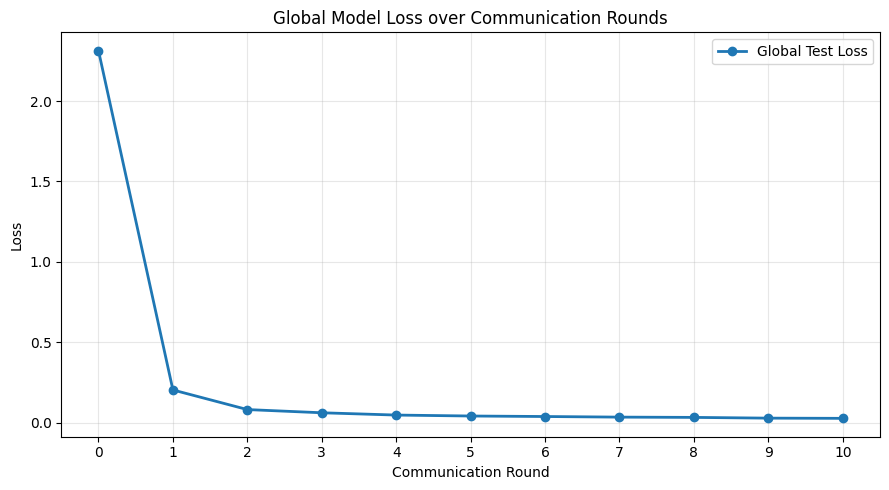

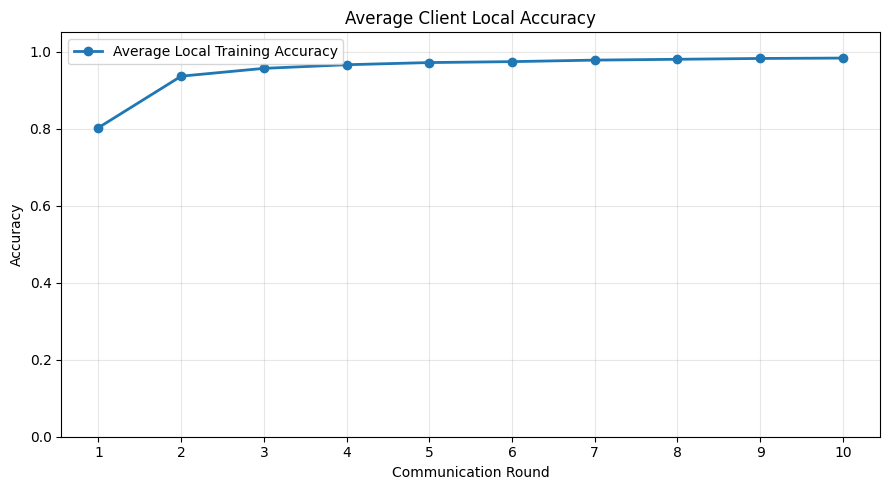

In [ ]:
# ==========================================
# Plot Accuracy and Loss Curves
# ==========================================

# Round 0 到 Round NUM_ROUNDS
round_axis = list(range(NUM_ROUNDS + 1))


# ------------------------------------------
# Global Test Accuracy Curve
# ------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    round_axis,
    global_test_accuracy_history,
    marker="o",
    linewidth=2,
    label="Global Test Accuracy"
)

plt.xlabel("Communication Round")
plt.ylabel("Accuracy")
plt.title("Global Model Accuracy over Communication Rounds")

plt.xticks(round_axis)
plt.ylim(0, 1.05)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------
# Global Test Loss Curve
# ------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    round_axis,
    global_test_loss_history,
    marker="o",
    linewidth=2,
    label="Global Test Loss"
)

plt.xlabel("Communication Round")
plt.ylabel("Loss")
plt.title("Global Model Loss over Communication Rounds")

plt.xticks(round_axis)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------
# 每一輪的平均 Local Accuracy
# 注意：Local History 不包含 Round 0
# ------------------------------------------

local_round_axis = list(range(1, NUM_ROUNDS + 1))

plt.figure(figsize=(9, 5))

plt.plot(
    local_round_axis,
    local_accuracy_history,
    marker="o",
    linewidth=2,
    label="Average Local Training Accuracy"
)

plt.xlabel("Communication Round")
plt.ylabel("Accuracy")
plt.title("Average Client Local Accuracy")

plt.xticks(local_round_axis)
plt.ylim(0, 1.05)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

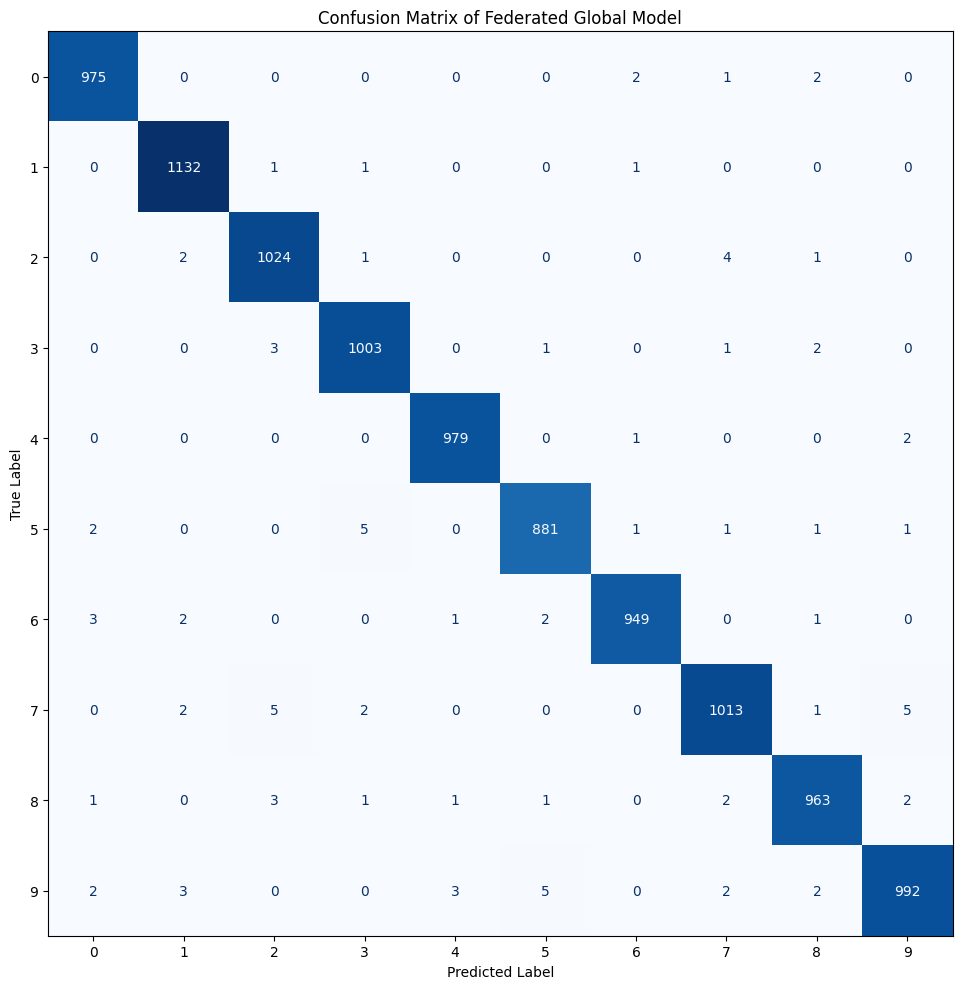

Classification Report
              precision    recall  f1-score   support

           0     0.9919    0.9949    0.9934       980
           1     0.9921    0.9974    0.9947      1135
           2     0.9884    0.9922    0.9903      1032
           3     0.9901    0.9931    0.9916      1010
           4     0.9949    0.9969    0.9959       982
           5     0.9899    0.9877    0.9888       892
           6     0.9948    0.9906    0.9927       958
           7     0.9893    0.9854    0.9873      1028
           8     0.9897    0.9887    0.9892       974
           9     0.9900    0.9832    0.9866      1009

    accuracy                         0.9911     10000
   macro avg     0.9911    0.9910    0.9911     10000
weighted avg     0.9911    0.9911    0.9911     10000



In [ ]:
# ==========================================
# Confusion Matrix and Classification Report
# ==========================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Global Model 對測試集輸出每一類的預測機率
prediction_probabilities = global_model.predict(
    x_test,
    verbose=0
)

# 找出機率最大的類別
y_pred = np.argmax(
    prediction_probabilities,
    axis=1
)

# 建立 Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

# 顯示 Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Confusion Matrix of Federated Global Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# 顯示 Precision、Recall、F1-score
print("Classification Report")
print("=" * 65)

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

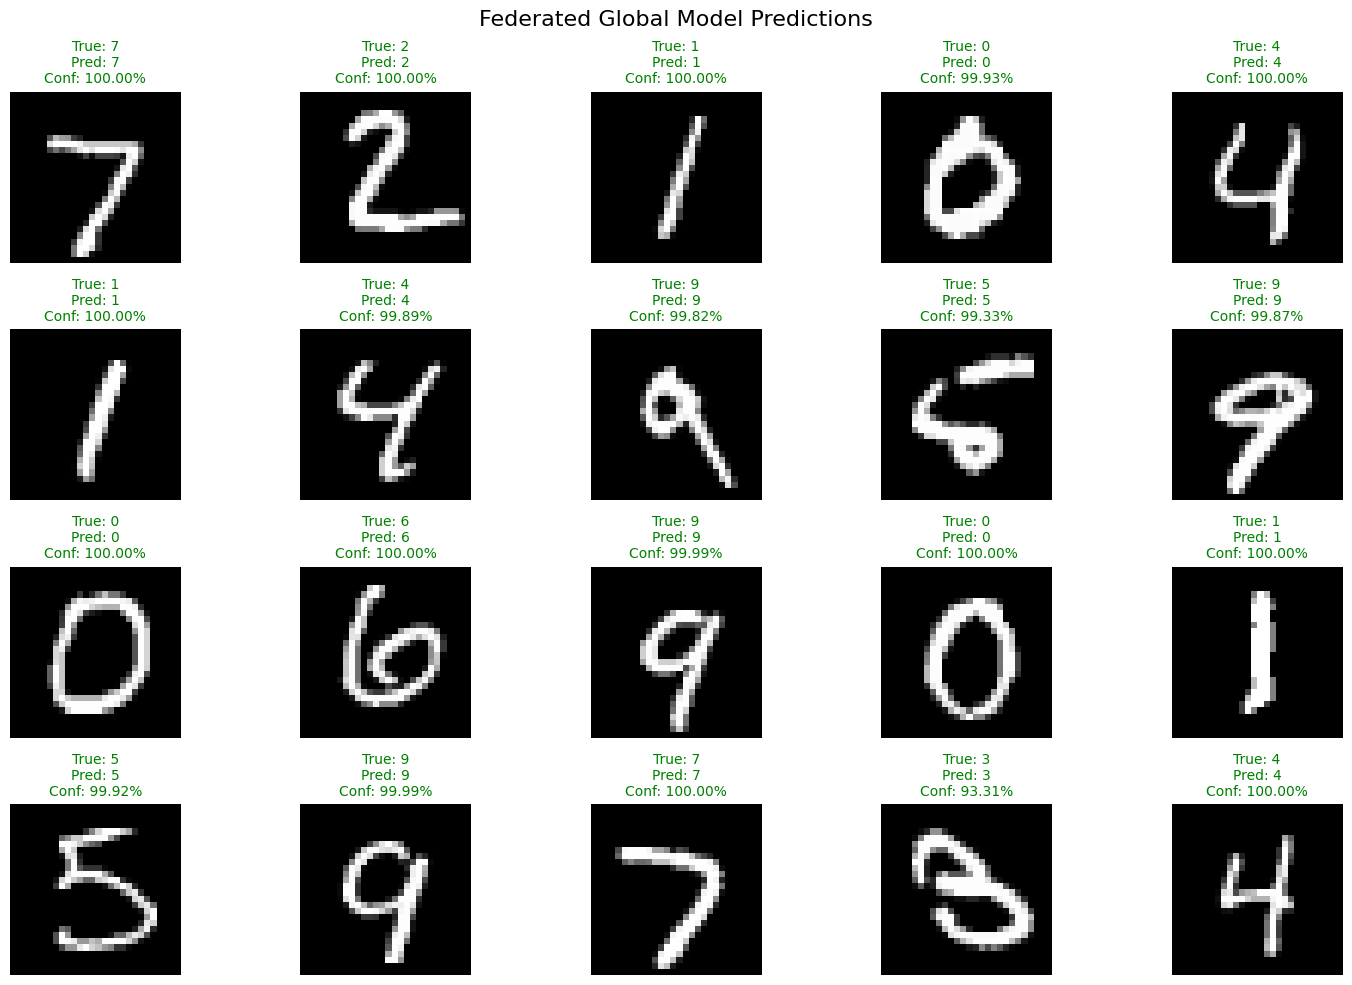

In [ ]:
# ==========================================
# Visualize Model Predictions
# ==========================================

# 顯示前20張測試圖片
NUM_DISPLAY_IMAGES = 20

plt.figure(figsize=(15, 10))

for i in range(NUM_DISPLAY_IMAGES):

    plt.subplot(4, 5, i + 1)

    # 移除灰階 Channel Dimension
    # (28, 28, 1) → (28, 28)
    image = x_test[i].squeeze()

    true_label = y_test[i]
    predicted_label = y_pred[i]

    # 模型對預測類別的信心
    confidence = prediction_probabilities[
        i,
        predicted_label
    ]

    plt.imshow(
        image,
        cmap="gray"
    )

    # 判斷預測是否正確
    if predicted_label == true_label:
        title_color = "green"
    else:
        title_color = "red"

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}\n"
        f"Conf: {confidence:.2%}",
        color=title_color,
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "Federated Global Model Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

Number of Misclassified Images: 89


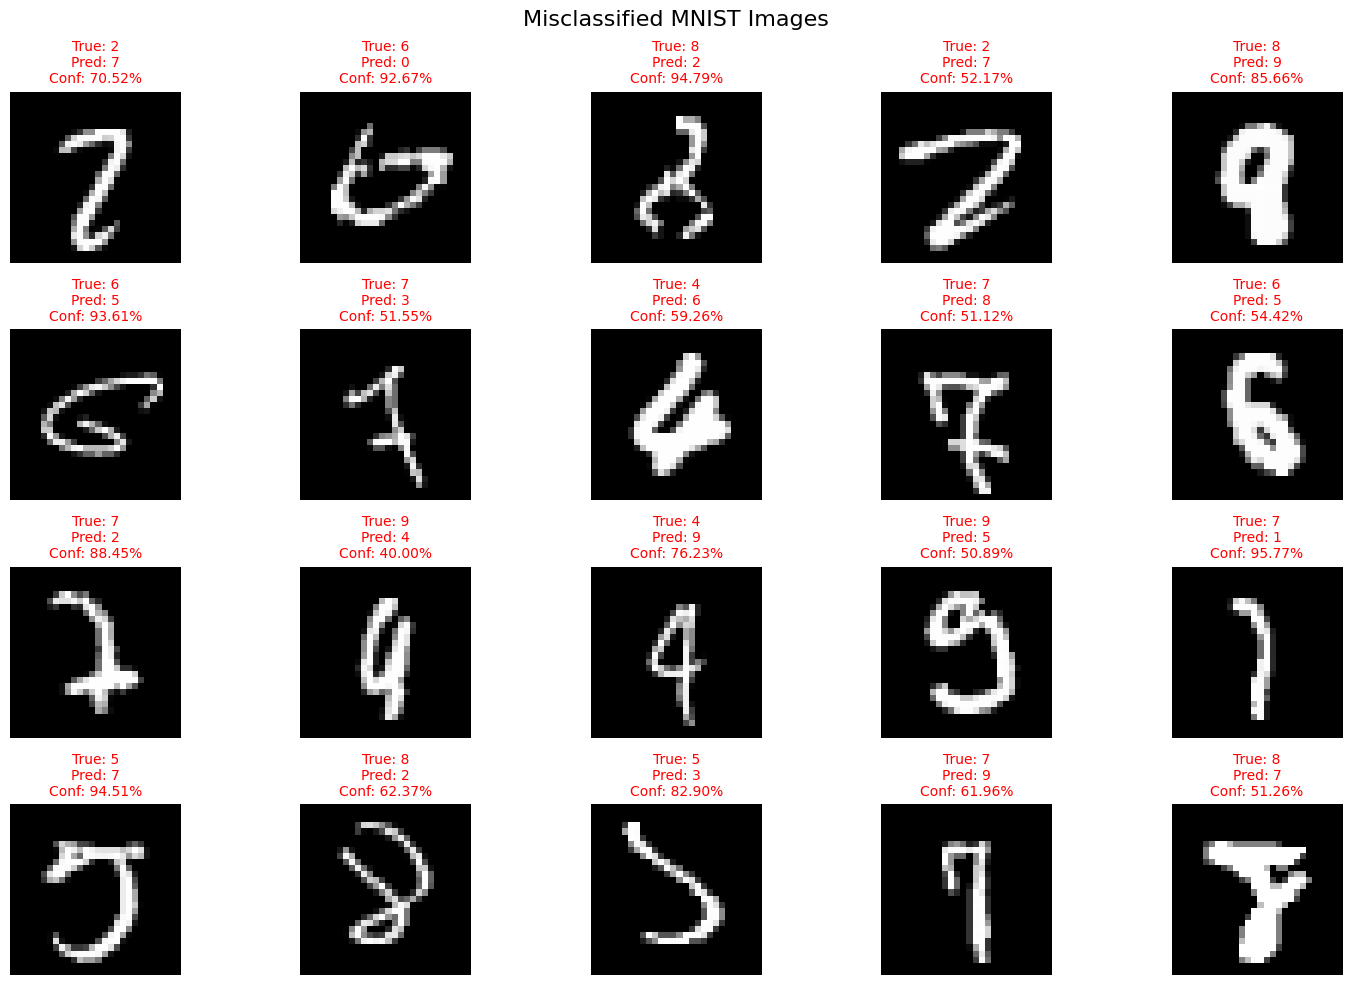

In [ ]:
# ==========================================
# Optional
# Display Misclassified Images
# ==========================================

# 找出預測錯誤的圖片索引
wrong_indices = np.where(
    y_pred != y_test
)[0]

print(
    "Number of Misclassified Images:",
    len(wrong_indices)
)

NUM_WRONG_IMAGES = min(
    20,
    len(wrong_indices)
)

plt.figure(figsize=(15, 10))

for plot_index in range(NUM_WRONG_IMAGES):

    image_index = wrong_indices[plot_index]

    plt.subplot(4, 5, plot_index + 1)

    image = x_test[image_index].squeeze()

    true_label = y_test[image_index]
    predicted_label = y_pred[image_index]

    confidence = prediction_probabilities[
        image_index,
        predicted_label
    ]

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}\n"
        f"Conf: {confidence:.2%}",
        color="red",
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "Misclassified MNIST Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Centralized Learning Baseline
# ==========================================

central_model = create_model()

history = central_model.fit(

    x_train,

    y_train,

    epochs=10,

    batch_size=64,

    validation_split=0.1,

    verbose=1

)

central_loss, central_accuracy = central_model.evaluate(

    x_test,

    y_test,

    verbose=0

)

print()

print("="*60)

print("Centralized Learning")

print("="*60)

print(f"Test Loss     : {central_loss:.4f}")

print(f"Test Accuracy : {central_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 57s 65ms/step - accuracy: 0.9228 - loss: 0.2563 - val_accuracy: 0.9848 - val_loss: 0.0564
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 92s 78ms/step - accuracy: 0.9739 - loss: 0.0873 - val_accuracy: 0.9883 - val_loss: 0.0421
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 61s 53ms/step - accuracy: 0.9807 - loss: 0.0653 - val_accuracy: 0.9893 - val_loss: 0.0384
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9843 - loss: 0.0518 - val_accuracy: 0.9888 - val_loss: 0.0399
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9865 - loss: 0.0437 - val_accuracy: 0.9907 - val_loss: 0.0366
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 55ms/step - accuracy: 0.9881 - loss: 0.0368 - val_accuracy: 0.9905 - val_loss: 0.0370
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 53ms/step - accuracy: 0.9895 - loss: 0.0322 - val_accuracy: 0.9915 - val_loss: 0.0332
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - accuracy: 0.9909 - loss: 0.0285 - 

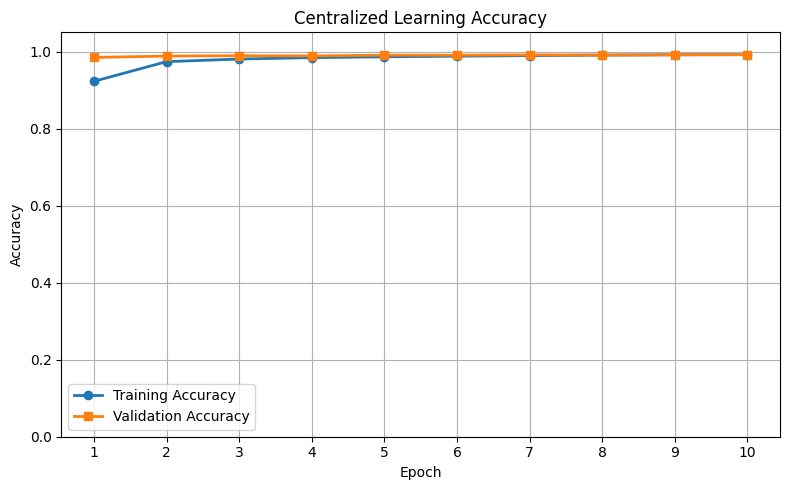

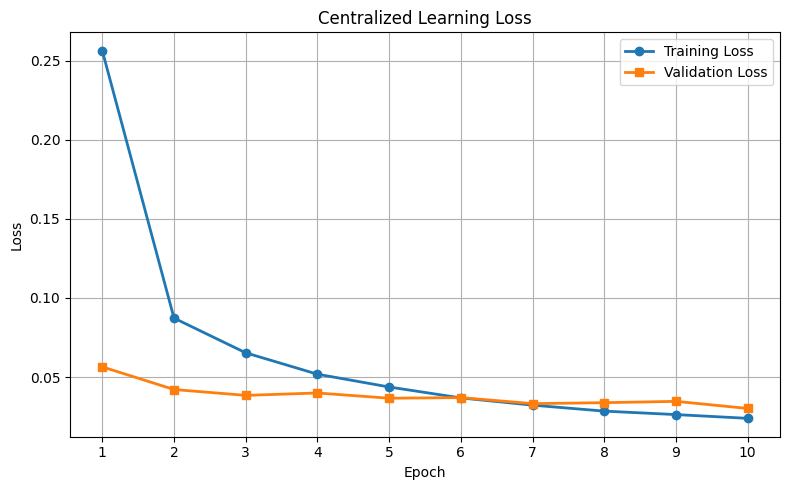

In [ ]:
# ==========================================
# Plot Accuracy and Loss Curves
# Centralized Learning
# ==========================================

import matplotlib.pyplot as plt

# Epoch 編號
epochs = range(1, len(history.history['loss']) + 1)

# =====================================================
# Training / Validation Accuracy
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    history.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title("Centralized Learning Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.xticks(epochs)

plt.ylim(0,1.05)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


# =====================================================
# Training / Validation Loss
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history.history['loss'],
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    epochs,
    history.history['val_loss'],
    marker='s',
    linewidth=2,
    label='Validation Loss'
)

plt.title("Centralized Learning Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.xticks(epochs)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

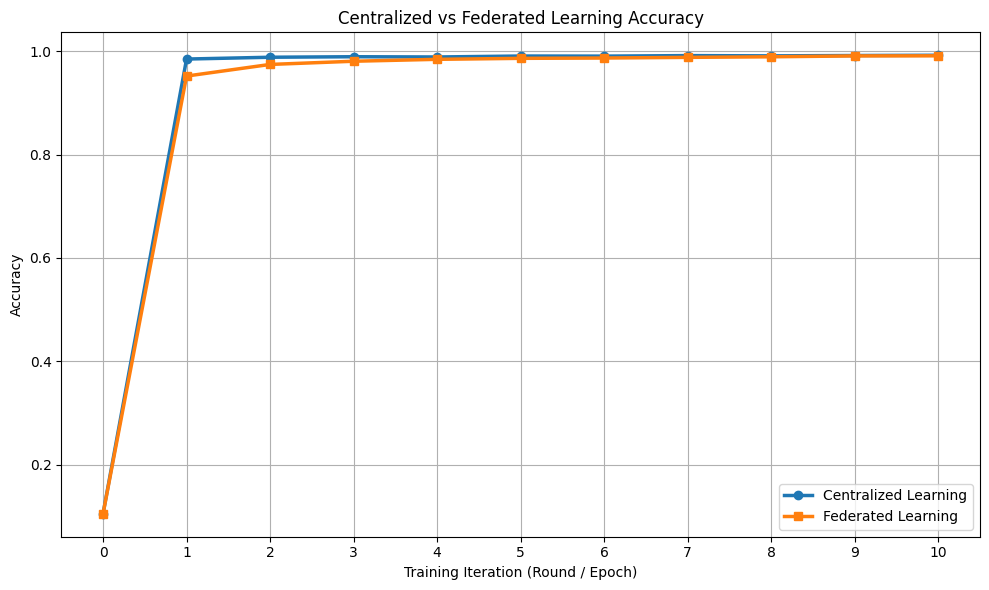

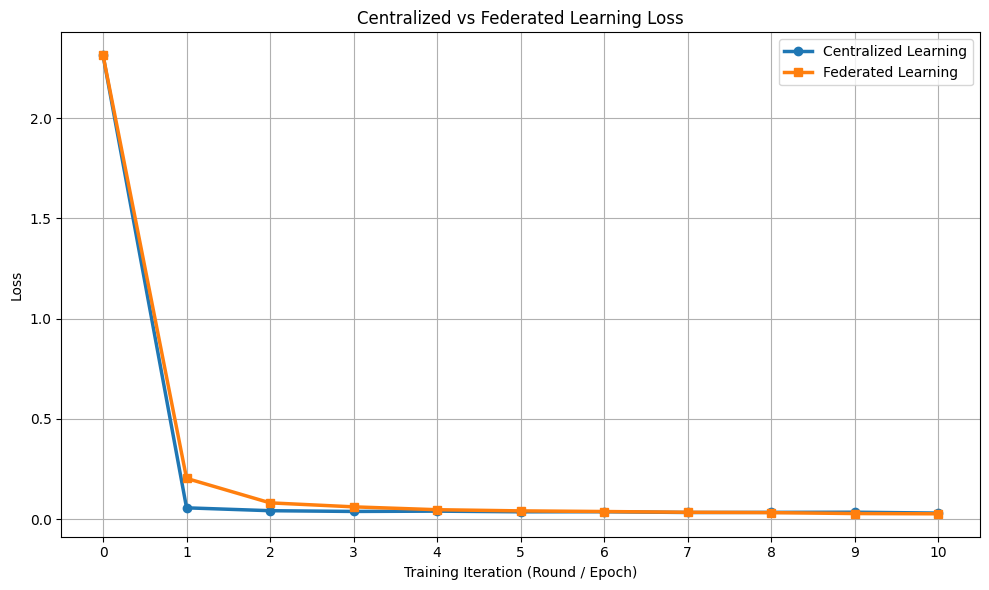

In [ ]:
# ==========================================
# Centralized vs Federated Learning
# Accuracy & Loss Comparison
# ==========================================

import matplotlib.pyplot as plt

# =====================================================
# Build History
# =====================================================

# Round 0 (Random Model)
central_accuracy_history = [initial_test_accuracy] + history.history['val_accuracy']
central_loss_history = [initial_test_loss] + history.history['val_loss']

# Federated Learning
fed_accuracy_history = global_test_accuracy_history
fed_loss_history = global_test_loss_history

iterations = range(len(fed_accuracy_history))

# =====================================================
# Accuracy Comparison
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    iterations,
    central_accuracy_history,
    marker='o',
    linewidth=2.5,
    markersize=6,
    label='Centralized Learning'
)

plt.plot(
    iterations,
    fed_accuracy_history,
    marker='s',
    linewidth=2.5,
    markersize=6,
    label='Federated Learning'
)

plt.title("Centralized vs Federated Learning Accuracy")

plt.xlabel("Training Iteration (Round / Epoch)")

plt.ylabel("Accuracy")

plt.xticks(iterations)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


# =====================================================
# Loss Comparison
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    iterations,
    central_loss_history,
    marker='o',
    linewidth=2.5,
    markersize=6,
    label='Centralized Learning'
)

plt.plot(
    iterations,
    fed_loss_history,
    marker='s',
    linewidth=2.5,
    markersize=6,
    label='Federated Learning'
)

plt.title("Centralized vs Federated Learning Loss")

plt.xlabel("Training Iteration (Round / Epoch)")

plt.ylabel("Loss")

plt.xticks(iterations)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# Performance Comparison
# ==========================================

print("="*70) # 就 70個 =

print("Performance Comparison")

print("="*70) # 就 70個 =

print(f"{'Method':<20}{'Accuracy':<15}{'Loss'}")

print("-"*70) # 就 70個 -

print(f"{'Centralized':<20}{central_accuracy:.4f}{'':<10}{central_loss:.4f}")

print(f"{'Federated':<20}{global_test_accuracy_history[-1]:.4f}{'':<10}{global_test_loss_history[-1]:.4f}")

print("="*70) # 就 70個 =

Performance Comparison
Method              Accuracy       Loss
----------------------------------------------------------------------
Centralized         0.9936          0.0235
Federated           0.9911          0.0267


# Discussion and Conclusion

## 1. Comparison between Centralized Learning and Federated Learning

### Centralized Learning

**Advantages**
- All training data are collected in a centralized server, allowing the model to learn from the complete dataset.
- Usually achieves the highest prediction accuracy and the fastest convergence.
- Simple implementation without communication or synchronization overhead.
- Suitable for applications where all data can be legally and efficiently collected.

**Disadvantages**
- Requires uploading all user data to a central server.
- Raises privacy and security concerns.
- Difficult to deploy when data sharing is restricted by regulations or organizations.
- High communication cost if raw data are large.

---

### Federated Learning

**Advantages**
- Raw data never leave local devices, providing better privacy protection.
- Multiple clients collaboratively train a global model without sharing their datasets.
- Suitable for distributed environments such as smartphones, hospitals, banks, IoT devices, and satellite networks.
- Enables collaborative learning among organizations that cannot exchange data.

**Disadvantages**
- Requires repeated communication between clients and the server.
- Longer training time due to multiple communication rounds.
- Model aggregation introduces additional computation overhead.
- Performance may degrade when client data distributions are highly heterogeneous (Non-IID).

---

## 2. Why are the MNIST recognition accuracies of the two methods so similar?

In this experiment, the performance of Centralized Learning and Federated Learning is very similar because of the following reasons:

1. **MNIST is a relatively simple dataset.**
   - Images are clean and contain only ten digit classes.
   - CNN models can easily achieve very high classification accuracy.

2. **The dataset is IID (Independent and Identically Distributed).**
   - Each client receives a randomly sampled subset of the training data.
   - Therefore, every client has a similar data distribution.
   - After model aggregation using FedAvg, the global model is close to the centralized model.

3. **Sufficient communication rounds were performed.**
   - After multiple rounds of local training and parameter aggregation, the Federated Learning model gradually converges toward the Centralized Learning model.

Consequently, the final testing accuracies of the two methods differ by only a small margin.

---

## 3. Time Complexity Analysis

Let

- **N** : Number of training samples
- **E** : Number of local training epochs
- **R** : Number of communication rounds
- **C** : Number of clients
- **W** : Number of model parameters

### Centralized Learning

Training complexity:

\[
O(EN)
\]

Only one model is trained on the complete dataset.

---

### Federated Learning

Training complexity:

\[
O(REN + RCW)
\]

where

- **REN** represents repeated local model training.
- **RCW** represents parameter communication and FedAvg aggregation.

Therefore, Federated Learning usually requires significantly longer execution time than Centralized Learning.

In this experiment, the training time of Federated Learning was much longer because five clients were trained sequentially for multiple communication rounds on a single machine. In practical deployments, these clients are typically trained in parallel on different devices, substantially reducing the wall-clock training time.

---

## 4. Application Scenarios

### Centralized Learning

Centralized Learning is generally the preferred choice whenever all data can be legally and efficiently collected in one location.

Typical applications include:

- Cloud AI services
- Enterprise data centers
- Manufacturing quality inspection
- Data analysis within a single organization
- Large-scale AI model training

When data collection is not restricted, Centralized Learning generally provides the highest accuracy, fastest convergence, and lowest implementation complexity.

---

### Federated Learning

Federated Learning is designed for scenarios where raw data cannot be centrally collected.

Typical applications include:

- Mobile keyboard prediction (Google Gboard)
- Medical image analysis across multiple hospitals
- Financial fraud detection across banks
- Internet of Things (IoT)
- Autonomous vehicles
- Multi-LEO satellite networks
- Federated Reinforcement Learning for distributed resource allocation

Instead of outperforming Centralized Learning in prediction accuracy, the primary objective of Federated Learning is to preserve data privacy while achieving performance close to that of Centralized Learning.

---

## Conclusion

From this experiment, it can be observed that Centralized Learning achieved slightly higher accuracy and required much less training time than Federated Learning. This result is expected because all training data were available at a centralized server.

Although Federated Learning introduces additional communication and computation overhead, it provides significant advantages in privacy preservation and distributed collaboration. Therefore, Federated Learning is particularly suitable for applications where data cannot be directly shared, making it an important technology for future intelligent distributed systems, including healthcare, IoT, autonomous vehicles, and satellite communication networks.

# Store And Move Models To MyDrive Through Google Colab

1. Create save path
2. Store models
3. Move the models to Mydrive

In [ ]:
# 掛載使用者的Google雲端硬碟 (drive/MyDrive) 到 Colab 的工作磁碟
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os
from pathlib import Path

save_dir = Path("saved_models")
save_dir.mkdir(exist_ok=True)
print(os.listdir(Path.cwd()))
print(Path.cwd())
print(os.listdir(Path.cwd() / 'drive'))
print(save_dir.resolve())
print(os.listdir(save_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['.config', 'drive', 'saved_models', 'sample_data']
/content
['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']
/content/saved_models
[]


In [ ]:
# Save Centralized Learning Model
central_model.save(save_dir / "Centralized_Model.keras")
print("Centralized Model Saved!")

# Save Federated Learning Global Model
global_model.save(save_dir / "Federated_Model.keras")
print("Federated Model Saved!")

Centralized Model Saved!
Federated Model Saved!


In [ ]:
print(os.listdir(Path.cwd()))
print(Path.cwd())
print(os.listdir(Path.cwd() / 'drive'))
print(save_dir.resolve())
print(os.listdir(save_dir))

['.config', 'Federated_Model.keras', 'Centralized_Model.keras', 'drive', 'saved_models', 'sample_data']
/content
['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']
/content/saved_models
['Federated_Model.keras', 'Centralized_Model.keras']


In [ ]:
# Move Centralized Learning Model To MyDrive
target_path = Path.cwd() / 'drive' / 'MyDrive' / "Centralized_Model.keras"
source_path = Path.cwd() / 'saved_models' / "Centralized_Model.keras"

shutil.move(source_path, target_path)

# Move Federated Learning Global Model To MyDrive
target_path = Path.cwd() / 'drive' / 'MyDrive' / "Federated_Model.keras"
source_path = Path.cwd() / 'saved_models' / "Federated_Model.keras"

shutil.move(source_path, target_path)

PosixPath('/content/drive/MyDrive/Federated_Model.keras')